## Vremenske serije

In [33]:
import pandas as pd
import numpy as np

student_vle = pd.read_csv("../data/raw/studentVle.csv")
print(student_vle.shape)
student_vle.head()

(10655280, 6)


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [34]:
student_vle["week"] = student_vle["date"] // 7
weekly_clicks = student_vle.groupby(["id_student", "code_module", "code_presentation", "week"])["sum_click"].sum().reset_index()
weekly_clicks.columns = ["id_student", "code_module", "code_presentation", "week", "total_clicks"]
print("Shape:", weekly_clicks.shape)
weekly_clicks.head(10)

#da li treba da se izbace nedelje pre pocetka???

Shape: (627031, 5)


,id_student,code_module,code_presentation,week,total_clicks
0,6516,AAA,2014J,-4,110
1,6516,AAA,2014J,-3,48
2,6516,AAA,2014J,-2,2
3,6516,AAA,2014J,-1,96
4,6516,AAA,2014J,0,229
5,6516,AAA,2014J,1,42
6,6516,AAA,2014J,2,79
7,6516,AAA,2014J,3,193
8,6516,AAA,2014J,4,69
9,6516,AAA,2014J,5,34


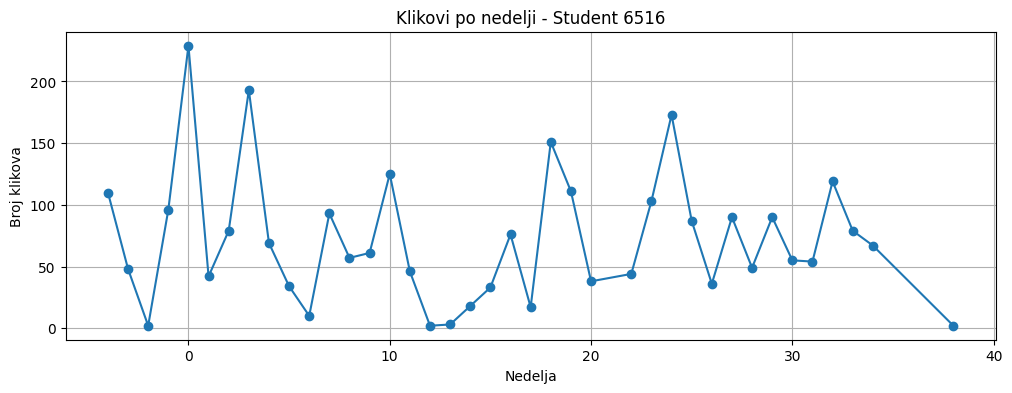

In [35]:
import matplotlib.pyplot as plt

student_id = 6516
modul = "AAA"
prezentacija = "2014J"

student_series = weekly_clicks[
    (weekly_clicks["id_student"] == student_id) &
    (weekly_clicks["code_module"] == modul) &
    (weekly_clicks["code_presentation"] == prezentacija)
].sort_values("week")

plt.figure(figsize=(12, 4))
plt.plot(student_series["week"], student_series["total_clicks"], marker="o")
plt.title(f"Klikovi po nedelji - Student {student_id}")
plt.xlabel("Nedelja")
plt.ylabel("Broj klikova")
plt.grid(True)
plt.show()

In [36]:
serija = student_series["total_clicks"].values

train_ts = serija[:-4]
test_ts = serija[-4:]
print("Train nedelje:", len(train_ts))
print("Test nedelje:", len(test_ts))

Train nedelje: 35
Test nedelje: 4


In [37]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

arima_model = ARIMA(train_ts, order=(1, 1, 1))
arima_fit = arima_model.fit()
forecast = arima_fit.forecast(steps=4)

print("Stvarne vrednosti:", test_ts)
print("Predikcija:", forecast.round(1))
print("MSE:", round(mean_squared_error(test_ts, forecast)))

Stvarne vrednosti: [119  79  67   2]
Predikcija: [69.8 71.9 72.2 72.2]
MSE: 1855


In [38]:
def napravi_lag_features(serija, n_lags=3):
    df_lag = pd.DataFrame(serija, columns=["clicks"])
    for lag in range(1, n_lags + 1):
        df_lag[f"lag_{lag}"] = df_lag["clicks"].shift(lag)
    df_lag = df_lag.dropna()
    return df_lag

lag_df = napravi_lag_features(serija, n_lags=3)
print(lag_df)

    clicks  lag_1  lag_2  lag_3
3       96    2.0   48.0  110.0
4      229   96.0    2.0   48.0
5       42  229.0   96.0    2.0
6       79   42.0  229.0   96.0
7      193   79.0   42.0  229.0
8       69  193.0   79.0   42.0
9       34   69.0  193.0   79.0
10      10   34.0   69.0  193.0
11      93   10.0   34.0   69.0
12      57   93.0   10.0   34.0
13      61   57.0   93.0   10.0
14     125   61.0   57.0   93.0
15      46  125.0   61.0   57.0
16       2   46.0  125.0   61.0
17       3    2.0   46.0  125.0
18      18    3.0    2.0   46.0
19      33   18.0    3.0    2.0
20      76   33.0   18.0    3.0
21      17   76.0   33.0   18.0
22     151   17.0   76.0   33.0
23     111  151.0   17.0   76.0
24      38  111.0  151.0   17.0
25      44   38.0  111.0  151.0
26     103   44.0   38.0  111.0
27     173  103.0   44.0   38.0
28      87  173.0  103.0   44.0
29      36   87.0  173.0  103.0
30      90   36.0   87.0  173.0
31      49   90.0   36.0   87.0
32      90   49.0   90.0   36.0
33      

In [39]:
X_lag = lag_df.drop(columns=["clicks"]).values
y_lag = lag_df["clicks"].values

X_lag_train = X_lag[:-4]
y_lag_train = y_lag[:-4]
X_lag_test = X_lag[-4:]
y_lag_test = y_lag[-4:]

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

rf_ts = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ts.fit(X_lag_train, y_lag_train)
y_pred_rf = rf_ts.predict(X_lag_test)

print("Stvarne vrednosti:", y_lag_test)
print("Predikcija:", y_pred_rf.round(1))
print("MSE:", round(mean_squared_error(y_lag_test, y_pred_rf), 2))
print("MAE:", round(mean_absolute_error(y_lag_test, y_pred_rf), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_lag_test, y_pred_rf)),2))

Stvarne vrednosti: [119  79  67   2]
Predikcija: [84.3 85.4 30.2 67.8]
MSE: 1731.27
MAE: 35.92
RMSE: 41.61


In [41]:
def napravi_lstm_sekvence(serija, n_lags=3):
    X, y = [], []
    for i in range(len(serija) - n_lags):
        X.append(serija[i:i+n_lags])
        y.append(serija[i+n_lags])
    return np.array(X), np.array(y)

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
serija_scaled = scaler.fit_transform(serija.reshape(-1, 1)).flatten()
X_lstm, y_lstm = napravi_lstm_sekvence(serija_scaled, n_lags=3)

X_lstm_train = X_lstm[:-4]
y_lstm_train = y_lstm[:-4]
X_lstm_test = X_lstm[-4:]
y_lstm_test = y_lstm[-4:]

In [43]:
import torch

X_lstm_train_t = torch.FloatTensor(X_lstm_train).unsqueeze(-1)
y_lstm_train_t = torch.FloatTensor(y_lstm_train).unsqueeze(-1)
X_lstm_test_t = torch.FloatTensor(X_lstm_test).unsqueeze(-1)

print("X train shape:", X_lstm_train_t.shape)
print("y train shape:", y_lstm_train_t.shape)

X train shape: torch.Size([32, 3, 1])
y train shape: torch.Size([32, 1])


In [44]:
import random
import numpy as np
import torch

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [45]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, num_layers=1, output_dim=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

lstm_model = LSTMModel()
criterion_lstm = nn.MSELoss()
optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=0.01)

print(lstm_model)

LSTMModel(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [46]:
epochs = 100
losses = []

for epoch in range(epochs):
    lstm_model.train()
    optimizer_lstm.zero_grad()
    y_pred_lstm = lstm_model(X_lstm_train_t)
    loss = criterion_lstm(y_pred_lstm, y_lstm_train_t)
    loss.backward()
    optimizer_lstm.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


Epoch 20/100, Loss: 0.0584
Epoch 40/100, Loss: 0.0557
Epoch 60/100, Loss: 0.0548
Epoch 80/100, Loss: 0.0529
Epoch 100/100, Loss: 0.0493


In [47]:
lstm_model.eval()

with torch.no_grad():
    y_pred_lstm_scaled = lstm_model(X_lstm_test_t).numpy()

y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled).flatten()
y_lstm_test_orig = scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).flatten()

print("Stvarne vrednosti:", y_lstm_test_orig.round(1))
print("Predikcija:", y_pred_lstm.round(1))
print("MSE:", round(mean_squared_error(y_lstm_test_orig, y_pred_lstm), 2))
print("MAE:", round(mean_absolute_error(y_lstm_test_orig, y_pred_lstm), 2))

Stvarne vrednosti: [119.  79.  67.   2.]
Predikcija: [76.7 79.  50.9 77. ]
MSE: 1918.83
MAE: 33.35


In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np


rezultati_ts = pd.DataFrame([
    {
        "model": "ARIMA (1,1,1)",
        "MSE": mean_squared_error(test_ts, forecast),
        "MAE": mean_absolute_error(test_ts, forecast),
        "RMSE": np.sqrt(mean_squared_error(test_ts, forecast))
    },
    {
        "model": "Random Forest",
        "MSE": mean_squared_error(y_lag_test, y_pred_rf),
        "MAE": mean_absolute_error(y_lag_test, y_pred_rf),
        "RMSE": np.sqrt(mean_squared_error(y_lag_test, y_pred_rf))
    },
    {
        "model": "LSTM",
        "MSE": mean_squared_error(y_lstm_test_orig, y_pred_lstm),
        "MAE": mean_absolute_error(y_lstm_test_orig, y_pred_lstm),
        "RMSE": np.sqrt(mean_squared_error(y_lstm_test_orig, y_pred_lstm))
    }
])

rezultati_ts.round(2)

,model,MSE,MAE,RMSE
0,"ARIMA (1,1,1)",1854.92,32.90,43.07
1,Random Forest,1731.27,35.92,41.61
2,LSTM,1918.83,33.35,43.80
